In [3]:
import random
from functools import partial
from omegaconf import DictConfig
import os
import torch
import rasterio
import numpy as np
from pathlib import Path
import h5py
from typing import Dict, Any
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from lib import config_utils
from lib import data_utils
from lib import visutils # gallery / apply_brightness_factor / sequence2gallery 

from lib.eval_tools import (
    Imputation,
    visualize_att_for_one_head_across_time,
    visualize_att_for_target_t_across_heads
)

from dataloader_CIRCA.datasets import CIRCA_ADAPTED2UTILISE_Dataset
from lib.data_utils import pad_collate

from typing import Any, Dict, Literal
import math
import torch
from prodict import Prodict
from torch import Tensor
from lib.data_utils import extract_sample
from lib import config_utils
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)   # ou FutureWarning, UserWarning, ...

In [4]:
def sample_to_batch(sample: dict) -> dict:
    batch = {}
    for k, v in sample.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.unsqueeze(dim=0)
        else:
            batch[k] = v
    return batch

### Set de imputation pour l'inférence

In [5]:
path_inference_config_file = Path("/home/SPeillet/rpg_3STR/cloud_reconstruction/U-TILISE/configs/config_run_eval.yaml")
path_ckpt_config_file = Path("/mnt/DATA_10T/data_rpg/outputs/U-TILISE/results/ALL_SAR_120_epochs_2025-07-11_16-56/config.yaml")
path_ckpt_pth = Path("/mnt/DATA_10T/data_rpg/outputs/U-TILISE/results/ALL_SAR_120_epochs_2025-07-11_16-56/checkpoints/Model_best.pth")
training_config_file = config_utils.read_config(path_ckpt_config_file)
inference_config_file = config_utils.read_config(path_inference_config_file)

temporal_window = 6

# Faire la différence entre l'imputation d'une TS (avec plusieurs intervalles de dates) et plusieurs observations.
inference_imputation = Imputation(
    config_file_train=path_inference_config_file, # Config permettant de faire la configuration de l'inference
    method="utilise",
    checkpoint=path_ckpt_pth,
    config_file_test=path_ckpt_config_file, # Fichier ayant servi à l'entrainement du modèle (update params model)
    temporal_window=temporal_window,
)

Loaded transforms from ./data/CIRCA_patches_datasets_with_transforms.json.
Checkpoint '/mnt/DATA_10T/data_rpg/outputs/U-TILISE/results/ALL_SAR_120_epochs_2025-07-11_16-56/checkpoints/Model_best.pth' loaded.
Chosen epoch: 109



In [6]:
from rasterio.windows import Window
bad_case_mgrs25 = "30TYS_row-4_col-4"
bad_case_window_str = 1536_512_256_256
bad_case_window = Window(1536, 512, 256, 256)

{'mgrs': '30UXV', 'mgrs25': '30UXV_row-2_col-2', 'window': '1536_1940_256_256'}


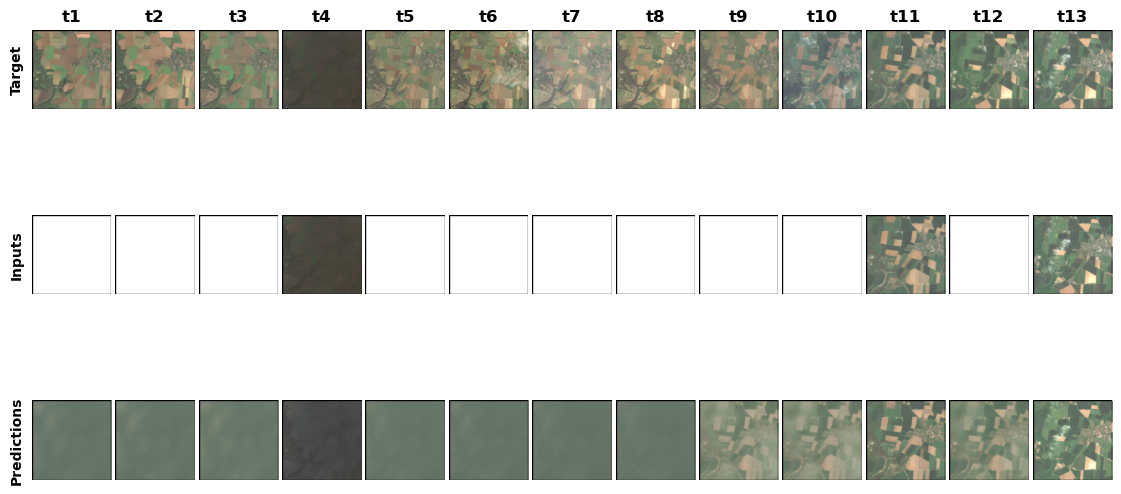

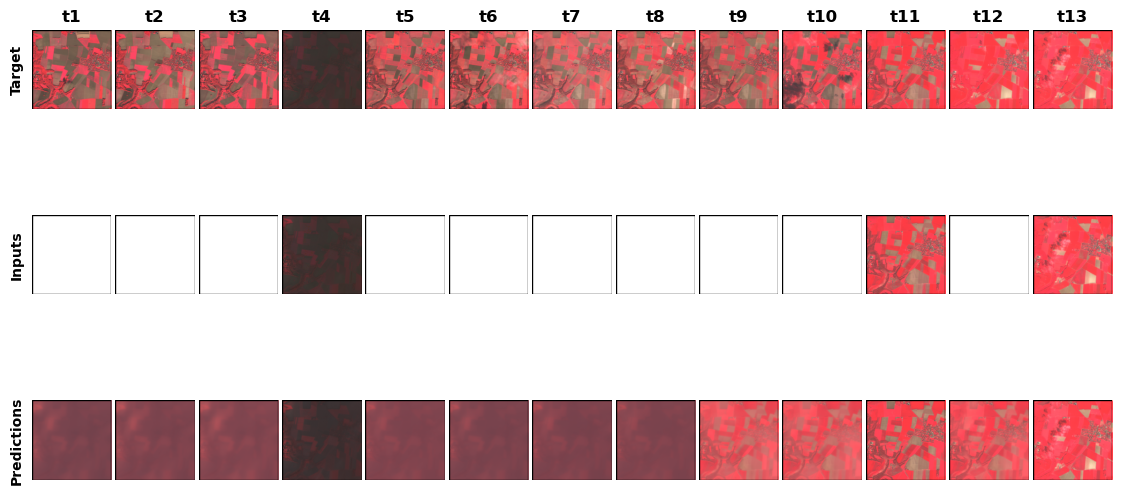

In [7]:
item = 500
# t_sampled = [2, 4, 6, 8, 9, 10, 13]
# t_masked = {"indices_masked": [1, 2, 4, 6]}

t_sampled = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
t_masked =  {"indices_masked": [0, 1, 2, 4, 5, 6, 7, 8, 9, 11]}

phase = "test"
BRIGHTNESS_FACTOR = 3
# Setup configuration
config_file = Path("./configs/config_run_train.yaml")
default_config_path = Path("./configs/default.yaml")
cfg_custom = config_utils.read_config(config_file)
cfg_default = config_utils.read_config(default_config_path)
config = OmegaConf.merge(cfg_default, cfg_custom)

config.data.hdf5_file = "/mnt/DATA_10T/data_rpg/circa/hdf5/CIRCA_CR_merged.hdf5"
config.mask.mask_type = 'random_fully_masked'
config.data.max_seq_length = None
config.training_settings.batch_size = 1
config.mask.ratio_masked_frames = 0.5
config.mask.intersect_real_cloud_masks = False
config.mask.dilate_cloud_masks = False

BRIGHTNESS_FACTOR = 3

dl1 = torch.utils.data.DataLoader(
    dataset=data_utils.get_dataset(config, phase="test"),
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=None,
    pin_memory=False,
    drop_last=False,
)

sample1 = dl1.dataset.__getitem__(item, t_sampled=t_sampled, t_masked=t_masked)
print(sample1["info"])
batch1 = sample_to_batch(sample1)

batch1, y_pred, att = inference_imputation.impute_sample(
    batch=batch1,
    return_att=True,
    # t_start=t_start,
    # t_end=t_end,
)

import matplotlib. pyplot as plt
import numpy as np
import matplotlib. patches as patches

images = torch.concatenate(
    [
        batch1['y'][0][:, sample1['c_index_rgb'], :, :].swapaxes(1, 3).swapaxes(1, 2),
        batch1['x'][0][:, sample1['c_index_rgb'], :, :].swapaxes(1, 3).swapaxes(1, 2),
        y_pred[0][:, sample1['c_index_rgb'], :, :].swapaxes(1, 3).swapaxes(1, 2),
    ],
    dim=0,
)

images = visutils.apply_brightness_factor(images, factor=BRIGHTNESS_FACTOR)
ncols = int(images.shape[0] / 3)
# Créer la figure avec 4 lignes et 6 colonnes
fig, axes = plt.subplots(nrows=3, ncols=ncols, figsize=(15, 7))

# Labels pour les colonnes (t0 à t5)
column_labels = [f't{i + 1}' for i in range(ncols + 1)]

# Afficher les images
for idx, ax in enumerate(axes.flat):
    ax.imshow(images[idx])
    ax.axis('off')  # Masquer les axes
    rect = patches.Rectangle((0, 0), 1, 1, 
                               transform=ax.transAxes,
                               fill=False, 
                               edgecolor='black', 
                               linewidth=1)
    ax.add_patch(rect)
    
    if idx < ncols:
        ax.set_title(column_labels[idx], fontsize=12, fontweight='bold')

plt.subplots_adjust(wspace=0.05, hspace=0.1)

row_labels = ['Target', 'Inputs', 'Predictions']
for i, label in enumerate(row_labels):
    axes[i, 0].annotate(label, 
                        xy=(-0.1, 0.5),
                        xycoords='axes fraction',
                        fontsize=10, 
                        fontweight='bold',
                        ha='right',
                        va='center',
                        rotation=90)

plt.subplots_adjust(left=0.18)
plt.savefig('ma_figure.png', dpi=300, bbox_inches='tight')

import matplotlib. pyplot as plt
import numpy as np
import matplotlib. patches as patches
c_index_rgnir = [6, 2, 1]
images = torch.concatenate(
    [
        batch1['y'][0][:, c_index_rgnir, :, :].swapaxes(1, 3).swapaxes(1, 2),
        batch1['x'][0][:, c_index_rgnir, :, :].swapaxes(1, 3).swapaxes(1, 2),
        y_pred[0][:, c_index_rgnir, :, :].swapaxes(1, 3).swapaxes(1, 2),
    ],
    dim=0,
)

images = visutils.apply_brightness_factor(images, factor=2)
ncols = int(images.shape[0] / 3)
# Créer la figure avec 4 lignes et 6 colonnes
fig, axes = plt.subplots(nrows=3, ncols=ncols, figsize=(15, 7))

# Labels pour les colonnes (t0 à t5)
column_labels = [f't{i + 1}' for i in range(ncols + 1)]

# Afficher les images
for idx, ax in enumerate(axes.flat):
    ax.imshow(images[idx])
    ax.axis('off')  # Masquer les axes
    rect = patches.Rectangle((0, 0), 1, 1, 
                               transform=ax.transAxes,
                               fill=False, 
                               edgecolor='black', 
                               linewidth=1)
    ax.add_patch(rect)
    
    if idx < ncols:
        ax.set_title(column_labels[idx], fontsize=12, fontweight='bold')

plt.subplots_adjust(wspace=0.05, hspace=0.1)

row_labels = ['Target', 'Inputs', 'Predictions']
for i, label in enumerate(row_labels):
    axes[i, 0].annotate(label, 
                        xy=(-0.1, 0.5),
                        xycoords='axes fraction',
                        fontsize=10, 
                        fontweight='bold',
                        ha='right',
                        va='center',
                        rotation=90)

plt.subplots_adjust(left=0.18)
plt.savefig('ma_figure.png', dpi=300, bbox_inches='tight')

In [13]:
batch1["y"][0][2]

tensor([[[0.1070, 0.1102, 0.1070,  ..., 0.1333, 0.1329, 0.1351],
         [0.1095, 0.1125, 0.1102,  ..., 0.1334, 0.1320, 0.1351],
         [0.1145, 0.1101, 0.1137,  ..., 0.1368, 0.1357, 0.1353],
         ...,
         [0.1131, 0.1220, 0.1167,  ..., 0.1295, 0.1318, 0.1330],
         [0.1200, 0.1188, 0.1168,  ..., 0.1372, 0.1373, 0.1331],
         [0.1144, 0.1140, 0.1155,  ..., 0.1318, 0.1350, 0.1324]],

        [[0.1128, 0.1213, 0.1199,  ..., 0.1834, 0.1866, 0.1838],
         [0.1202, 0.1241, 0.1196,  ..., 0.1847, 0.1818, 0.1798],
         [0.1302, 0.1221, 0.1200,  ..., 0.1787, 0.1796, 0.1806],
         ...,
         [0.1312, 0.1446, 0.1408,  ..., 0.1704, 0.1647, 0.1664],
         [0.1420, 0.1396, 0.1326,  ..., 0.1748, 0.1679, 0.1655],
         [0.1378, 0.1417, 0.1403,  ..., 0.1710, 0.1673, 0.1634]],

        [[0.1086, 0.1130, 0.1160,  ..., 0.1397, 0.1392, 0.1380],
         [0.1148, 0.1167, 0.1134,  ..., 0.1393, 0.1390, 0.1400],
         [0.1219, 0.1163, 0.1164,  ..., 0.1480, 0.1408, 0.

In [12]:
batch1["x"][0][2]

tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        ...,

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1., 

In [1]:
from dataloader_CIRCA.datasets.cr_metrics import display_metrics
content = {'ssim': 0.7374271750450134, 'ssim_band_0': 0.5912029147148132, 'ssim_band_1': 0.6703476309776306, 'ssim_band_2': 0.6797220706939697, 'ssim_band_3': 0.7477619647979736, 'ssim_band_4': 0.7863912582397461, 'ssim_band_5': 0.8052210211753845, 'ssim_band_6': 0.7585447430610657, 'ssim_band_7': 0.8025939464569092, 'ssim_band_8': 0.7775372862815857, 'ssim_band_9': 0.7549473643302917, 'ssim_images_occluded_input_pixels': 0.3441600501537323, 'ssim_images_occluded_input_pixels_band_0': 0.29336708784103394, 'ssim_images_occluded_input_pixels_band_1': 0.31345799565315247, 'ssim_images_occluded_input_pixels_band_2': 0.31642457842826843, 'ssim_images_occluded_input_pixels_band_3': 0.34495365619659424, 'ssim_images_occluded_input_pixels_band_4': 0.36866194009780884, 'ssim_images_occluded_input_pixels_band_5': 0.3749874234199524, 'ssim_images_occluded_input_pixels_band_6': 0.35759517550468445, 'ssim_images_occluded_input_pixels_band_7': 0.37796035408973694, 'ssim_images_occluded_input_pixels_band_8': 0.3519976735115051, 'ssim_images_occluded_input_pixels_band_9': 0.34219709038734436, 'ssim_images_observed_input_pixels': 0.8238043785095215, 'ssim_images_observed_input_pixels_band_0': 0.6439085006713867, 'ssim_images_observed_input_pixels_band_1': 0.7432167530059814, 'ssim_images_observed_input_pixels_band_2': 0.754206657409668, 'ssim_images_observed_input_pixels_band_3': 0.8370950222015381, 'ssim_images_observed_input_pixels_band_4': 0.8830863237380981, 'ssim_images_observed_input_pixels_band_5': 0.9057212471961975, 'ssim_images_observed_input_pixels_band_6': 0.8486369848251343, 'ssim_images_observed_input_pixels_band_7': 0.9015865921974182, 'ssim_images_observed_input_pixels_band_8': 0.874387264251709, 'ssim_images_observed_input_pixels_band_9': 0.8462042212486267, 'rmse': 713.296630859375, 'rmse_occluded_input_pixels': 1900.8316650390625, 'rmse_observed_input_pixels': 90.00763702392578, 'psnr': 27.877971649169922, 'psnr_occluded_input_pixels': 17.237627029418945, 'psnr_observed_input_pixels': 41.059486389160156, 'mse': 895025.9375, 'mse_occluded_input_pixels': 4428351.5, 'mse_observed_input_pixels': 8430.5888671875, 'r2': 0.6853586435317993, 'r2_observed_input_pixels': 0.9916310906410217, 'mae': 334.5092468261719, 'mae_occluded_input_pixels': 1464.3958740234375, 'mae_observed_input_pixels': 62.23255920410156, 'rmse_band_0': 406.2430419921875, 'rmse_band_0_occluded_input_pixels': 1039.707275390625, 'rmse_band_0_observed_input_pixels': 91.41378784179688, 'psnr_band_0': 31.597265243530273, 'psnr_band_0_occluded_input_pixels': 22.757038116455078, 'psnr_band_0_observed_input_pixels': 41.3378791809082, 'mse_band_0': 307003.59375, 'mse_band_0_occluded_input_pixels': 1446281.75, 'mse_band_0_observed_input_pixels': 10162.564453125, 'r2_band_0': 0.5377708673477173, 'r2_band_0_observed_input_pixels': 0.9283822178840637, 'mae_band_0': 211.81797790527344, 'mae_band_0_occluded_input_pixels': 830.170166015625, 'mae_band_0_observed_input_pixels': 65.22541809082031, 'rmse_band_1': 455.5390319824219, 'rmse_band_1_occluded_input_pixels': 1211.3336181640625, 'rmse_band_1_observed_input_pixels': 67.59675598144531, 'psnr_band_1': 31.569032669067383, 'psnr_band_1_occluded_input_pixels': 21.362512588500977, 'psnr_band_1_observed_input_pixels': 43.771419525146484, 'mse_band_1': 387057.28125, 'mse_band_1_occluded_input_pixels': 1891298.75, 'mse_band_1_observed_input_pixels': 5084.72119140625, 'r2_band_1': 0.5573095083236694, 'r2_band_1_observed_input_pixels': 0.9661127328872681, 'mae_band_1': 224.4259490966797, 'mae_band_1_occluded_input_pixels': 977.5172119140625, 'mae_band_1_observed_input_pixels': 45.707740783691406, 'rmse_band_2': 474.0531921386719, 'rmse_band_2_occluded_input_pixels': 1239.2259521484375, 'rmse_band_2_observed_input_pixels': 88.8136978149414, 'psnr_band_2': 30.53338050842285, 'psnr_band_2_occluded_input_pixels': 20.944263458251953, 'psnr_band_2_observed_input_pixels': 41.38517379760742, 'mse_band_2': 403710.0625, 'mse_band_2_occluded_input_pixels': 1955638.75, 'mse_band_2_observed_input_pixels': 8759.9423828125, 'r2_band_2': 0.6058497428894043, 'r2_band_2_observed_input_pixels': 0.9700202345848083, 'mae_band_2': 240.09146118164062, 'mae_band_2_occluded_input_pixels': 991.4947509765625, 'mae_band_2_observed_input_pixels': 62.667598724365234, 'rmse_band_3': 562.564453125, 'rmse_band_3_occluded_input_pixels': 1504.3902587890625, 'rmse_band_3_observed_input_pixels': 72.33193969726562, 'psnr_band_3': 30.018850326538086, 'psnr_band_3_occluded_input_pixels': 19.358278274536133, 'psnr_band_3_observed_input_pixels': 43.08964920043945, 'mse_band_3': 574043.375, 'mse_band_3_occluded_input_pixels': 2830755.0, 'mse_band_3_observed_input_pixels': 5723.2802734375, 'r2_band_3': 0.5750238299369812, 'r2_band_3_observed_input_pixels': 0.9791166186332703, 'mae_band_3': 278.5540771484375, 'mae_band_3_occluded_input_pixels': 1224.1239013671875, 'mae_band_3_observed_input_pixels': 52.65743637084961, 'rmse_band_4': 799.5867309570312, 'rmse_band_4_occluded_input_pixels': 2138.17333984375, 'rmse_band_4_observed_input_pixels': 88.83704376220703, 'psnr_band_4': 27.286346435546875, 'psnr_band_4_occluded_input_pixels': 16.370084762573242, 'psnr_band_4_observed_input_pixels': 41.192840576171875, 'mse_band_4': 1144020.125, 'mse_band_4_occluded_input_pixels': 5647581.5, 'mse_band_4_observed_input_pixels': 8187.833984375, 'r2_band_4': 0.5773153901100159, 'r2_band_4_observed_input_pixels': 0.9854975938796997, 'mae_band_4': 391.85821533203125, 'mae_band_4_occluded_input_pixels': 1736.2515869140625, 'mae_band_4_observed_input_pixels': 65.38934326171875, 'rmse_band_5': 878.7980346679688, 'rmse_band_5_occluded_input_pixels': 2370.891845703125, 'rmse_band_5_observed_input_pixels': 72.90117645263672, 'psnr_band_5': 27.203310012817383, 'psnr_band_5_occluded_input_pixels': 15.488415718078613, 'psnr_band_5_observed_input_pixels': 42.88859558105469, 'mse_band_5': 1403485.5, 'mse_band_5_occluded_input_pixels': 6940955.0, 'mse_band_5_observed_input_pixels': 5525.71142578125, 'r2_band_5': 0.6026818156242371, 'r2_band_5_observed_input_pixels': 0.9929078817367554, 'mae_band_5': 417.4657287597656, 'mae_band_5_occluded_input_pixels': 1912.0457763671875, 'mae_band_5_observed_input_pixels': 52.716766357421875, 'rmse_band_6': 936.017333984375, 'rmse_band_6_occluded_input_pixels': 2465.204833984375, 'rmse_band_6_observed_input_pixels': 135.895751953125, 'psnr_band_6': 25.14525032043457, 'psnr_band_6_occluded_input_pixels': 15.155790328979492, 'psnr_band_6_observed_input_pixels': 37.51058578491211, 'mse_band_6': 1521401.25, 'mse_band_6_occluded_input_pixels': 7503939.5, 'mse_band_6_observed_input_pixels': 19078.677734375, 'r2_band_6': 0.5967758893966675, 'r2_band_6_observed_input_pixels': 0.9789627194404602, 'mae_band_6': 468.1197509765625, 'mae_band_6_occluded_input_pixels': 1992.672119140625, 'mae_band_6_observed_input_pixels': 98.35609436035156, 'rmse_band_7': 932.7105712890625, 'rmse_band_7_occluded_input_pixels': 2505.1220703125, 'rmse_band_7_observed_input_pixels': 85.46543884277344, 'psnr_band_7': 26.45711326599121, 'psnr_band_7_occluded_input_pixels': 15.0648832321167, 'psnr_band_7_observed_input_pixels': 41.47578811645508, 'mse_band_7': 1575598.5, 'mse_band_7_occluded_input_pixels': 7780655.0, 'mse_band_7_observed_input_pixels': 7502.48974609375, 'r2_band_7': 0.6001474261283875, 'r2_band_7_observed_input_pixels': 0.9913564324378967, 'mae_band_7': 448.2943115234375, 'mae_band_7_occluded_input_pixels': 2018.9415283203125, 'mae_band_7_observed_input_pixels': 64.08717346191406, 'rmse_band_8': 760.526123046875, 'rmse_band_8_occluded_input_pixels': 2048.86181640625, 'rmse_band_8_observed_input_pixels': 75.83274841308594, 'psnr_band_8': 27.984378814697266, 'psnr_band_8_occluded_input_pixels': 16.729000091552734, 'psnr_band_8_observed_input_pixels': 42.63239288330078, 'mse_band_8': 1027251.1875, 'mse_band_8_occluded_input_pixels': 5187907.5, 'mse_band_8_observed_input_pixels': 6100.87353515625, 'r2_band_8': 0.5809674263000488, 'r2_band_8_observed_input_pixels': 0.9872117042541504, 'mae_band_8': 368.8548583984375, 'mae_band_8_occluded_input_pixels': 1669.7884521484375, 'mae_band_8_observed_input_pixels': 55.11909484863281, 'rmse_band_9': 597.560546875, 'rmse_band_9_occluded_input_pixels': 1592.8046875, 'rmse_band_9_observed_input_pixels': 87.29850769042969, 'psnr_band_9': 29.01419448852539, 'psnr_band_9_occluded_input_pixels': 18.72422218322754, 'psnr_band_9_observed_input_pixels': 41.49603271484375, 'mse_band_9': 606685.8125, 'mse_band_9_occluded_input_pixels': 3098514.75, 'mse_band_9_observed_input_pixels': 8179.8837890625, 'r2_band_9': 0.6069526076316833, 'r2_band_9_observed_input_pixels': 0.9836763739585876, 'mae_band_9': 295.6106872558594, 'mae_band_9_occluded_input_pixels': 1290.955322265625, 'mae_band_9_observed_input_pixels': 60.39862823486328, 'sam': 0.1156076118350029, 'sam_observed_input_pixels': 0.026494964957237244, 'r2_occluded_input_pixels': 0.16793793439865112, 'r2_band_0_occluded_input_pixels': 0.10362517833709717, 'r2_band_1_occluded_input_pixels': 0.10578130930662155, 'r2_band_2_occluded_input_pixels': 0.11749328672885895, 'r2_band_3_occluded_input_pixels': 0.10434038192033768, 'r2_band_4_occluded_input_pixels': 0.10772156715393066, 'r2_band_5_occluded_input_pixels': 0.11967162042856216, 'r2_band_6_occluded_input_pixels': 0.11686200648546219, 'r2_band_7_occluded_input_pixels': 0.1201389878988266, 'r2_band_8_occluded_input_pixels': 0.10797245800495148, 'r2_band_9_occluded_input_pixels': 0.11902374774217606, 'sam_occluded_input_pixels': 0.49131083488464355}
display_metrics(content)

                   Cloud Reconstruction Metrics                   
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃      Metric ┃   Overall    ┃ Occluded Pixels ┃ Observed Pixels ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│         MAE │   334.5092   │    1464.3959    │     62.2326     │
│  MAE_BAND_0 │   211.8180   │    830.1702     │     65.2254     │
│  MAE_BAND_1 │   224.4259   │    977.5172     │     45.7077     │
│  MAE_BAND_2 │   240.0915   │    991.4948     │     62.6676     │
│  MAE_BAND_3 │   278.5541   │    1224.1239    │     52.6574     │
│  MAE_BAND_4 │   391.8582   │    1736.2516    │     65.3893     │
│  MAE_BAND_5 │   417.4657   │    1912.0458    │     52.7168     │
│  MAE_BAND_6 │   468.1198   │    1992.6721    │     98.3561     │
│  MAE_BAND_7 │   448.2943   │    2018.9415    │     64.0872     │
│  MAE_BAND_8 │   368.8549   │    1669.7885    │     55.1191     │
│  MAE_BAND_9 │   295.6107   │    1290.9553    │     60.3986     │
│         MSE │ 895025.9375  │  4428351.5000   │    8430.5889    │
│  MSE_BAND_0 │ 307003.5938  │  1446281.7500   │   10162.5645    │
│  MSE_BAND_1 │ 387057.2812  │  1891298.7500   │    5084.7212    │
│  MSE_BAND_2 │ 403710.0625  │  1955638.7500   │    8759.9424    │
│  MSE_BAND_3 │ 574043.3750  │  2830755.0000   │    5723.2803    │
│  MSE_BAND_4 │ 1144020.1250 │  5647581.5000   │    8187.8340    │
│  MSE_BAND_5 │ 1403485.5000 │  6940955.0000   │    5525.7114    │
│  MSE_BAND_6 │ 1521401.2500 │  7503939.5000   │   19078.6777    │
│  MSE_BAND_7 │ 1575598.5000 │  7780655.0000   │    7502.4897    │
│  MSE_BAND_8 │ 1027251.1875 │  5187907.5000   │    6100.8735    │
│  MSE_BAND_9 │ 606685.8125  │  3098514.7500   │    8179.8838    │
│        PSNR │   27.8780    │     17.2376     │     41.0595     │
│ PSNR_BAND_0 │   31.5973    │     22.7570     │     41.3379     │
│ PSNR_BAND_1 │   31.5690    │     21.3625     │     43.7714     │
│ PSNR_BAND_2 │   30.5334    │     20.9443     │     41.3852     │
│ PSNR_BAND_3 │   30.0189    │     19.3583     │     43.0896     │
│ PSNR_BAND_4 │   27.2863    │     16.3701     │     41.1928     │
│ PSNR_BAND_5 │   27.2033    │     15.4884     │     42.8886     │
│ PSNR_BAND_6 │   25.1453    │     15.1558     │     37.5106     │
│ PSNR_BAND_7 │   26.4571    │     15.0649     │     41.4758     │
│ PSNR_BAND_8 │   27.9844    │     16.7290     │     42.6324     │
│ PSNR_BAND_9 │   29.0142    │     18.7242     │     41.4960     │
│          R2 │    0.6854    │     0.1679      │     0.9916      │
│   R2_BAND_0 │    0.5378    │     0.1036      │     0.9284      │
│   R2_BAND_1 │    0.5573    │     0.1058      │     0.9661      │
│   R2_BAND_2 │    0.6058    │     0.1175      │     0.9700      │
│   R2_BAND_3 │    0.5750    │     0.1043      │     0.9791      │
│   R2_BAND_4 │    0.5773    │     0.1077      │     0.9855      │
│   R2_BAND_5 │    0.6027    │     0.1197      │     0.9929      │
│   R2_BAND_6 │    0.5968    │     0.1169      │     0.9790      │
│   R2_BAND_7 │    0.6001    │     0.1201      │     0.9914      │
│   R2_BAND_8 │    0.5810    │     0.1080      │     0.9872      │
│   R2_BAND_9 │    0.6070    │     0.1190      │     0.9837      │
│        RMSE │   713.2966   │    1900.8317    │     90.0076     │
│ RMSE_BAND_0 │   406.2430   │    1039.7073    │     91.4138     │
│ RMSE_BAND_1 │   455.5390   │    1211.3336    │     67.5968     │
│ RMSE_BAND_2 │   474.0532   │    1239.2260    │     88.8137     │
│ RMSE_BAND_3 │   562.5645   │    1504.3903    │     72.3319     │
│ RMSE_BAND_4 │   799.5867   │    2138.1733    │     88.8370     │
│ RMSE_BAND_5 │   878.7980   │    2370.8918    │     72.9012     │
│ RMSE_BAND_6 │   936.0173   │    2465.2048    │    135.8958     │
│ RMSE_BAND_7 │   932.7106   │    2505.1221    │     85.4654     │
│ RMSE_BAND_8 │   760.5261   │    2048.8618    │     75.8327     │
│ RMSE_BAND_9 │   597.5605   │    1592.8047    │     87.2985     │
│         SAM │    0.1156    │     0.4913      

In [5]:
import json
from dataloader_CIRCA.datasets.cr_metrics import display_metrics
from pathlib import Path
store_dai = Path("/mnt/stores/store_dai")
path_metrics = store_dai / "tmp/speillet/metrics/metrics_per_bands_masked_corrected/metrics_per_bands_masked_corrected_random_fully_masked/test_stats.json"
content = json.load(open(path_metrics))
display_metrics(content)

                  Cloud Reconstruction Metrics                   
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃      Metric ┃   Overall   ┃ Occluded Pixels ┃ Observed Pixels ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│         MAE │  116.9895   │    571.5205     │     65.1225     │
│  MAE_BAND_0 │   91.9614   │    313.9548     │     66.1839     │
│  MAE_BAND_1 │   79.1358   │    354.8425     │     47.1882     │
│  MAE_BAND_2 │  101.2413   │    426.8769     │     61.4394     │
│  MAE_BAND_3 │  101.8068   │    456.3513     │     62.2626     │
│  MAE_BAND_4 │  126.5594   │    653.5753     │     67.2058     │
│  MAE_BAND_5 │  128.4881   │    759.6072     │     54.7744     │
│  MAE_BAND_6 │  167.7531   │    801.0916     │     95.2922     │
│  MAE_BAND_7 │  138.4118   │    787.8929     │     64.0583     │
│  MAE_BAND_8 │  113.6592   │    627.0595     │     57.8529     │
│  MAE_BAND_9 │  120.8778   │    533.9506     │     74.9687     │
│         MSE │ 100487.1484 │  1192953.0000   │    9716.8955    │
│  MSE_BAND_0 │ 77480.6562  │   524590.1875   │   10060.9150    │
│  MSE_BAND_1 │ 71982.1406  │   593786.8125   │    5682.6650    │
│  MSE_BAND_2 │ 83870.0781  │   696248.7500   │    8896.0762    │
│  MSE_BAND_3 │ 81655.7500  │   822142.0625   │    7947.9897    │
│  MSE_BAND_4 │ 110943.0234 │  1424064.3750   │    9652.3135    │
│  MSE_BAND_5 │ 132019.2812 │  1788166.5000   │    6378.6729    │
│  MSE_BAND_6 │ 153176.8906 │  1926777.0000   │   19334.4355    │
│  MSE_BAND_7 │ 138770.8281 │  1954986.0000   │    8163.0488    │
│  MSE_BAND_8 │ 84906.0469  │  1318722.2500   │    7461.8452    │
│  MSE_BAND_9 │ 70066.2500  │   880050.7500   │   13590.9785    │
│        PSNR │   34.7365   │     25.2972     │     40.6628     │
│ PSNR_BAND_0 │   37.6035   │     31.4846     │     40.7966     │
│ PSNR_BAND_1 │   38.6722   │     30.3921     │     43.4797     │
│ PSNR_BAND_2 │   36.3978   │     27.8774     │     41.3876     │
│ PSNR_BAND_3 │   36.6094   │     28.0273     │     41.6164     │
│ PSNR_BAND_4 │   34.6574   │     24.9978     │     40.8460     │
│ PSNR_BAND_5 │   34.5841   │     23.5184     │     42.5105     │
│ PSNR_BAND_6 │   32.1618   │     22.9995     │     37.8077     │
│ PSNR_BAND_7 │   34.0001   │     23.3779     │     41.3668     │
│ PSNR_BAND_8 │   35.3458   │     25.4127     │     41.9838     │
│ PSNR_BAND_9 │   34.6709   │     26.1780     │     39.6593     │
│          R2 │   0.9394    │     0.7100      │     0.9917      │
│   R2_BAND_0 │   0.8187    │     0.4077      │     0.9175      │
│   R2_BAND_1 │   0.8680    │     0.4596      │     0.9652      │
│   R2_BAND_2 │   0.8688    │     0.4558      │     0.9684      │
│   R2_BAND_3 │   0.8765    │     0.4618      │     0.9723      │
│   R2_BAND_4 │   0.8930    │     0.4721      │     0.9844      │
│   R2_BAND_5 │   0.9044    │     0.4817      │     0.9924      │
│   R2_BAND_6 │   0.8937    │     0.4775      │     0.9804      │
│   R2_BAND_7 │   0.9071    │     0.4990      │     0.9912      │
│   R2_BAND_8 │   0.9030    │     0.4722      │     0.9869      │
│   R2_BAND_9 │   0.8933    │     0.4822      │     0.9771      │
│        RMSE │  236.1998   │    751.7359     │     95.9892     │
│ RMSE_BAND_0 │  168.8752   │    426.9464     │     95.9647     │
│ RMSE_BAND_1 │  159.5867   │    470.1863     │     71.1973     │
│ RMSE_BAND_2 │  195.7672   │    568.1201     │     90.0447     │
│ RMSE_BAND_3 │  192.7858   │    585.1774     │     86.3966     │
│ RMSE_BAND_4 │  244.2786   │    797.8105     │     94.8319     │
│ RMSE_BAND_5 │  265.4445   │    923.0380     │     77.7514     │
│ RMSE_BAND_6 │  309.1588   │    969.7932     │    134.7587     │
│ RMSE_BAND_7 │  275.7420   │    950.3489     │     88.2806     │
│ RMSE_BAND_8 │  223.7583   │    757.9033     │     83.4375     │
│ RMSE_BAND_9 │  221.5121   │    666.1289     │    110.6742     │
│         SAM │   0.0436    │     0.1192      │     0.0290      │
│        SSIM │   0.7754    │     0.4749